# Importing Libraries and Data

Libraries

In [1]:
import json
import time
from datetime import datetime, timedelta, timezone
import pandas as pd
from matplotlib import pyplot as plt

Data

In [2]:
with open('C:/Users/ashut/Desktop/DDoS/data/traffic_with_ddos_and_peak.json', 'r') as i:
  first_log = json.load(i)

with open('C:/Users/ashut/Desktop/DDoS/data/traffic_with_ddos_and_peak (1).json') as j:
  second_log = json.load(j)

with open('C:/Users/ashut/Desktop/DDoS/data/traffic_with_ddos_and_peak (2).json', 'r') as k:
  third_log = json.load(k)

In [3]:
first_df = pd.DataFrame(first_log)
second_df = pd.DataFrame(second_log)
third_df = pd.DataFrame(third_log)

# Preprocessing

Create relative timestamp (UNIX timestamp)

In [4]:
def UNIX_time(df):

  # Convert timestamp to datetime
  df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')

  # Convert the 'date_time' column to UNIX timestamp
  df['unix_timestamp'] = df['timestamp'].astype('int64') // 10**9  # Divide by 10^9 to get seconds

  return df

In [5]:
first_df = UNIX_time(first_df)
second_df = UNIX_time(second_df)
third_df = UNIX_time(third_df)

Sort according to time

In [6]:
first_df.sort_values(by='unix_timestamp', inplace=True)
second_df.sort_values(by='unix_timestamp', inplace=True)
third_df.sort_values(by='unix_timestamp', inplace=True)

Create Time Windows

In [7]:
def create_windows(df):
    # Define the size of each window
    window_size = 1  # 2 seconds

    # Create empty lists to store counts and differences
    traffic_in_window_1 = []
    traffic_in_window_2 = []
    traffic_in_window_3 = []
    traffic_in_window_4 = []

    # Define a sliding window
    start_time = df['unix_timestamp'].min()
    previous_count = None  # Variable to store the count of the previous window

    while start_time + (4 * window_size) <= df['unix_timestamp'].max():
        # Define the time windows
        first_window = (start_time, start_time + window_size)
        second_window = (start_time + window_size, start_time + 2 * window_size)
        third_window = (start_time + 2 * window_size, start_time + 3 * window_size)
        fourth_window = (start_time + 3 * window_size, start_time + 4 * window_size)

        # Count the number of requests in each window
        count_1st = df[(df['unix_timestamp'] >= first_window[0]) & (df['unix_timestamp'] < first_window[1])].shape[0]
        count_2nd = df[(df['unix_timestamp'] >= second_window[0]) & (df['unix_timestamp'] < second_window[1])].shape[0]
        count_3rd = df[(df['unix_timestamp'] >= third_window[0]) & (df['unix_timestamp'] < third_window[1])].shape[0]
        count_4th = df[(df['unix_timestamp'] >= fourth_window[0]) & (df['unix_timestamp'] < fourth_window[1])].shape[0]

        # Calculate differences
        if previous_count is None:
            diff_1st = count_1st  # Or use a default value
        else:
            diff_1st = count_1st - previous_count

        diff_2nd = count_2nd - count_1st
        diff_3rd = count_3rd - count_2nd
        diff_4th = count_4th - count_3rd

        # Append the differences to the lists
        traffic_in_window_1.append(diff_1st)
        traffic_in_window_2.append(diff_2nd)
        traffic_in_window_3.append(diff_3rd)
        traffic_in_window_4.append(diff_4th)

        # Update the previous_count and move the window by 2 seconds (sliding mechanism)
        previous_count = count_1st
        start_time += 1

    # Create a new DataFrame with the collected data
    feature_df = pd.DataFrame({
        'traffic in window 1': traffic_in_window_1,
        'traffic in window 2': traffic_in_window_2,
        'traffic in window 3': traffic_in_window_3,
        'traffic in window 4': traffic_in_window_4
    })
    return feature_df

In [8]:
first_features = create_windows(first_df)
second_features = create_windows(second_df)
third_features = create_windows(third_df)

In [9]:
def trajectory_filter(df):

    # Calculate the sum of the values in each row
    df['sum'] = df.sum(axis=1)
    
    # Filter out rows with negative sums (downward trajectory)
    filtered_df = df[df['sum'] >= 0]
    
    # Drop the 'sum' column if not needed
    filtered_df = filtered_df.drop(columns=['sum'])
    
    return filtered_df

In [10]:
first_filtered = trajectory_filter(first_features)
second_filtered = trajectory_filter(second_features)
third_filtered = trajectory_filter(third_features)

Quick Check-Up
1. Sort by 1st column to get best examples of donwtime
2. Sort by 4th column to get best examples of DDoS

In [11]:
first_filtered.sort_values(by='traffic in window 3', ascending=False)

,traffic in window 1,traffic in window 2,traffic in window 3,traffic in window 4
3626,-1,7,55,-5
9017,1,32,40,-1
9016,-1,1,32,40
6600,1,-2,21,-3
7201,1,1,19,15
...,...,...,...,...
2488,-3,8,-10,5
9048,2,4,-10,4
9024,-1,8,-11,7
7238,4,4,-11,7


In [12]:
second_filtered.sort_values(by='traffic in window 3', ascending=False)

,traffic in window 1,traffic in window 2,traffic in window 3,traffic in window 4
7210,0,0,19,5
9013,0,-1,15,8
3612,0,9,13,3
6615,-1,2,12,-7
4216,1,0,12,-5
...,...,...,...,...
3649,-2,4,-8,9
9025,2,8,-9,6
9018,3,2,-9,9
9074,4,4,-10,2


In [13]:
third_filtered.sort_values(by='traffic in window 3', ascending=False)

,traffic in window 1,traffic in window 2,traffic in window 3,traffic in window 4
9025,0,-2,16,4
6615,3,-4,13,5
7213,0,4,12,-2
3607,1,0,11,6
4213,-1,4,11,6
...,...,...,...,...
9048,5,2,-8,1
6658,0,8,-8,5
2473,2,5,-9,11
2448,-6,10,-9,6


Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
def scale_windows(df):
    # Initialize the scaler
    #scaler = MinMaxScaler(feature_range=(0, 1))
    scaler = StandardScaler()

    # Define which columns to scale
    feature_columns = df.columns  # Adjust this as necessary

    # Fit and transform the feature columns
    scaled_features = scaler.fit_transform(df[feature_columns])

    # Create a DataFrame from the scaled features
    scaled_df = pd.DataFrame(scaled_features, columns=feature_columns)

    return scaled_df

In [33]:
first_scaled = scale_windows(first_filtered)
second_scaled = scale_windows(second_filtered)
third_scaled = scale_windows(third_filtered)

# Model Training (Unsupervised)



Isolation Forest

In [17]:
from sklearn.ensemble import IsolationForest

In [35]:
first_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
second_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
third_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)

In [36]:
first_forest.fit(first_scaled)
second_forest.fit(second_scaled)
third_forest.fit(third_scaled)

IsolationForest(contamination=0.1, random_state=42)

# Analysis

In [37]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

First Data

In [39]:
first_filtered_clustered = first_filtered.copy()
first_filtered_clustered['clusters'] = first_forest.predict(first_scaled)
first_filtered_clustered.sort_values(by='traffic in window 4', ascending=False)

,traffic in window 1,traffic in window 2,traffic in window 3,traffic in window 4,clusters
3625,1,-1,7,55,-1
9016,-1,1,32,40,-1
9015,1,-1,1,32,-1
6599,0,1,-2,21,-1
7200,-2,1,1,19,-1
...,...,...,...,...,...
9018,32,40,-1,-10,-1
3694,6,6,-1,-10,-1
9038,5,-8,15,-11,-1
9087,9,-4,7,-11,-1


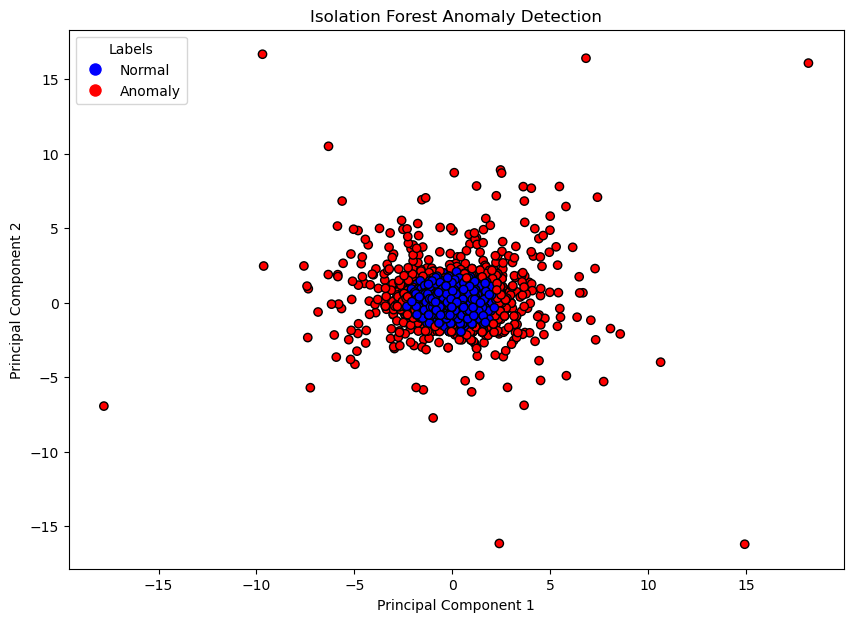

In [54]:
# Apply PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(first_scaled)

# Fit Isolation Forest and predict labels
labels = first_forest.predict(first_scaled)  # -1 for anomalies, 1 for normal points

# Convert labels to color mapping (anomalies = red, normal = blue)
colors = ['blue' if label == 1 else 'red' for label in labels]

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, marker='o', edgecolor='k')

# Create a legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Normal'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Anomaly')
]
plt.legend(handles=handles, title='Labels')

plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

Second Data

In [47]:
second_filtered_clustered = second_filtered.copy()
second_filtered_clustered['clusters'] = second_forest.predict(second_scaled)
second_filtered_clustered.sort_values(by='traffic in window 4', ascending=False)

,traffic in window 1,traffic in window 2,traffic in window 3,traffic in window 4,clusters
7209,0,0,0,19,-1
9012,-1,0,-1,15,-1
3611,-1,0,9,13,-1
4215,-1,1,0,12,-1
6614,1,-1,2,12,-1
...,...,...,...,...,...
9093,5,-6,8,-6,-1
6615,-1,2,12,-7,-1
3631,3,-3,11,-8,-1
9024,2,2,8,-9,-1


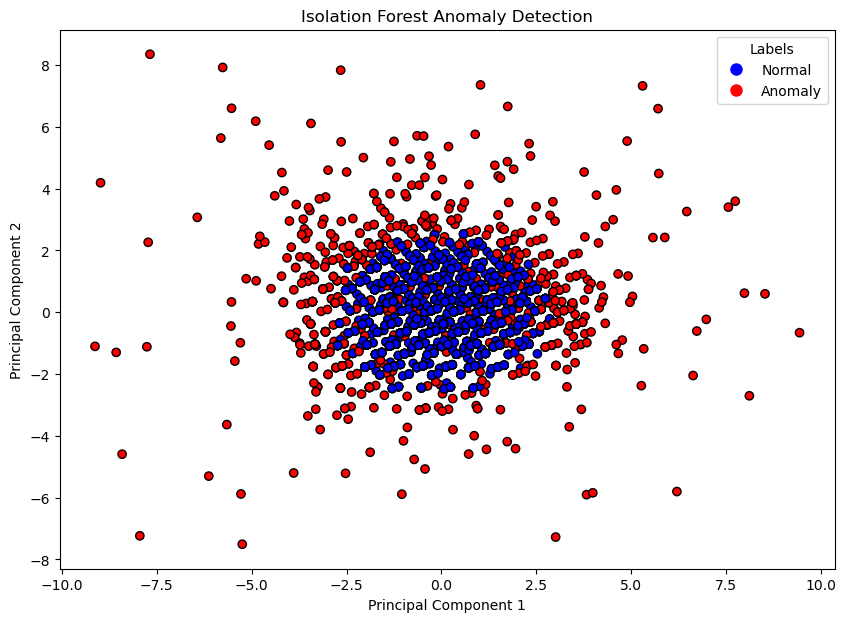

In [53]:
# Apply PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(second_scaled)

# Fit Isolation Forest and predict labels
labels = second_forest.predict(second_scaled)  # -1 for anomalies, 1 for normal points

# Convert labels to color mapping (anomalies = red, normal = blue)
colors = ['blue' if label == 1 else 'red' for label in labels]

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, marker='o', edgecolor='k')

# Create a legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Normal'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Anomaly')
]
plt.legend(handles=handles, title='Labels')

plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

Third Data

In [50]:
third_filtered_clustered = third_filtered.copy()
third_filtered_clustered['clusters'] = third_forest.predict(third_scaled)
third_filtered_clustered.sort_values(by='traffic in window 4', ascending=False)

,traffic in window 1,traffic in window 2,traffic in window 3,traffic in window 4,clusters
9024,1,0,-2,16,-1
6614,0,3,-4,13,-1
7212,1,0,4,12,-1
3606,-3,1,0,11,-1
2473,2,5,-9,11,-1
...,...,...,...,...,...
4267,-1,2,5,-6,-1
3652,2,-2,6,-6,-1
6681,3,4,1,-6,-1
9075,2,-2,7,-7,-1


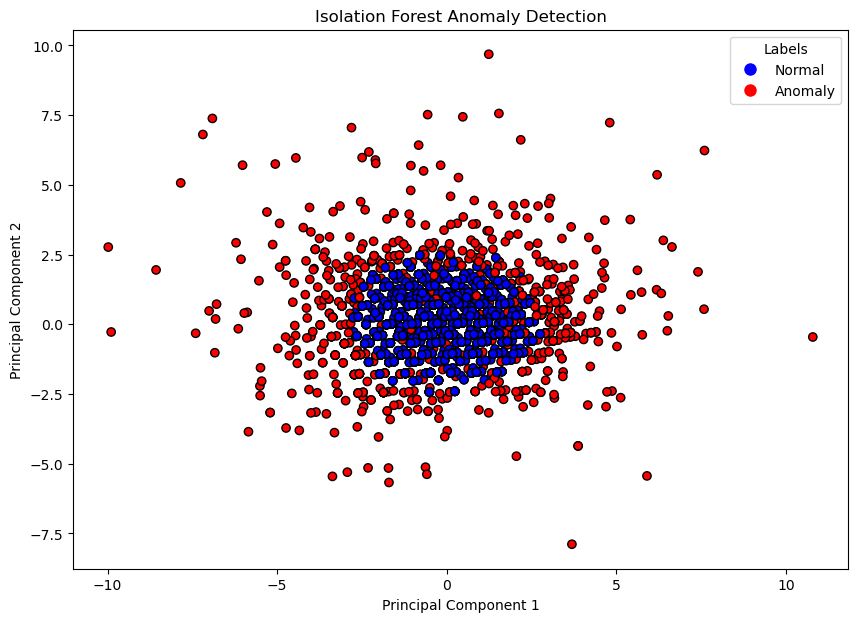

In [52]:
# Apply PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(third_scaled)

# Fit Isolation Forest and predict labels
labels = third_forest.predict(third_scaled)  # -1 for anomalies, 1 for normal points

# Convert labels to color mapping (anomalies = red, normal = blue)
colors = ['blue' if label == 1 else 'red' for label in labels]

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, marker='o', edgecolor='k')

# Create a legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Normal'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Anomaly')
]
plt.legend(handles=handles, title='Labels')

plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Conclusion

# above tables, namely first_features_clustered; second_features_clustered; and third_features_clustered show, when sorted:

# first data: 1 for DDoS, 2 for Benign, 0 for downtime
# second data: 0 for DDoS, 2 for Benign, 1 for downtime
# third data: 0 for DDoS, 2 for Benign, 1 for Downtime